In [ ]:
%load_ext autoreload
%autoreload 2
from two_spring_block import CoupledSpringBlock
from matplotlib import pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [117]:
def get_single_phase(tq, t: np.ndarray):
    if tq < min(t) or tq > max(t):
        return np.NaN

    dt = (t - tq)

    if np.min(np.abs(dt)) == 0:
        index = np.argmin(np.abs(dt))
        t1 = 0
        if index == 0:
            T = dt[index + 1]
        elif index == len(dt) - 1:
            T = dt[index - 1]
        else:
            T = np.mean(dt[[index - 1, index + 1]])

    else:
        dt_pos = dt[dt >= 0]
        dt_neg = dt[dt < 0]

        t1 = min(-dt_neg)
        t2 = min(dt_pos)

        T = t1 + t2

    phase = 2 * np.pi * t1 / T

    return phase

/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:96: RuntimeWarning: overflow encountered in exp
  dth = (Vpl_t * np.exp(-th) - V) / self.dc  # change in RS state (theta)
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:90: RuntimeWarning: overflow encountered in exp
  V = Vpl_t * np.exp(Y[[0, 2]])
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:101: RuntimeWarning: invalid value encountered in subtract
  Yp[[0, 2]] = (kv - self.b * self.sigma * dth) / (
/Users/kdascher/miniforge3/envs/torch_earthquake_stat/lib/python3.10/site-packages/scipy/integrate/_ivp/rk.py:109: RuntimeWarning: invalid value encountered in divide
  return norm(self._estimate_error(K, h) / scale)


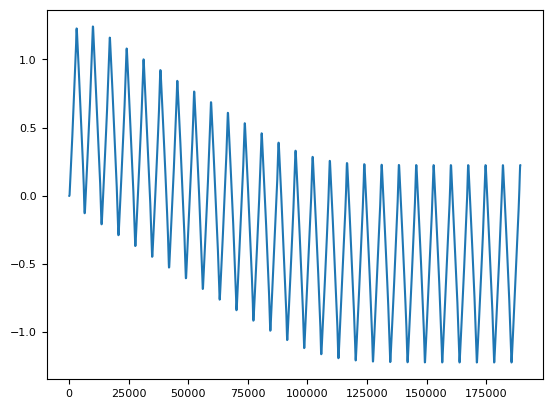

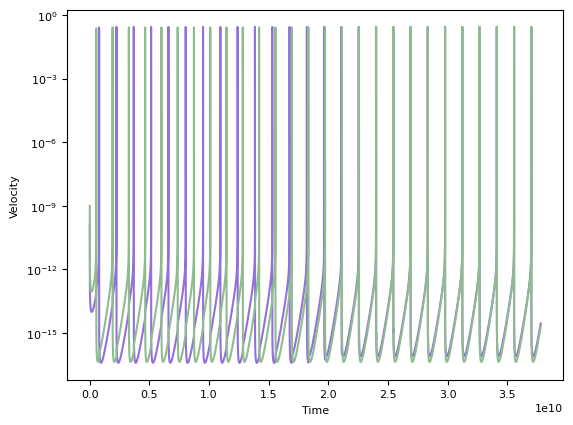

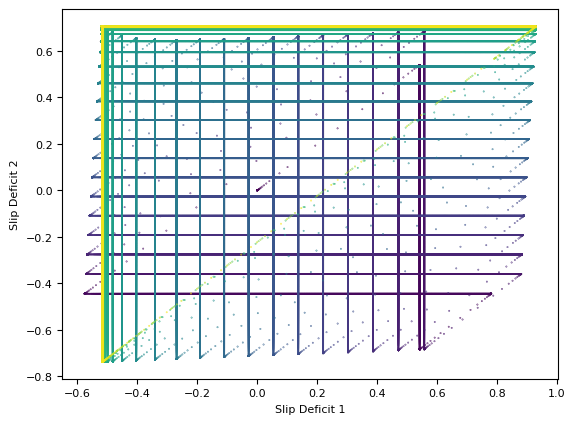

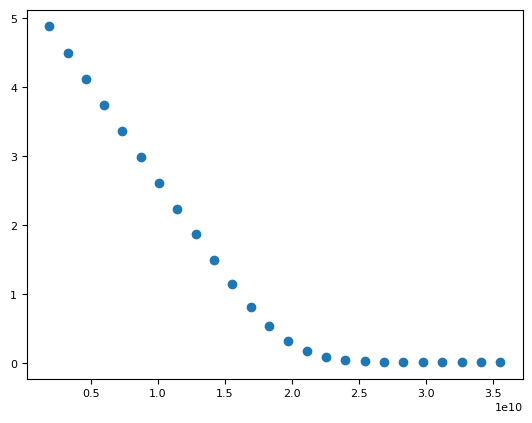

In [126]:
run_time = 1200*3.15e7
model = CoupledSpringBlock(
    sigma=np.array([10.0,9.5]), 
    k1=-1,
    k2=0.05,
    k3=0.05,
    Y=[-2,0,0,0],
    dc=0.0001,
)
model.simulate(run_time)
fig, ax = plt.subplots()    
ax.plot(model.slip_deficit[0,:] - model.slip_deficit[1,:])

model.plot_results()
model.plot_orbits()

tA, tB = model.get_events()
phases = [get_single_phase(tq, tA) for tq in tB]
fig, ax = plt.subplots()
ax.scatter(tB,phases)


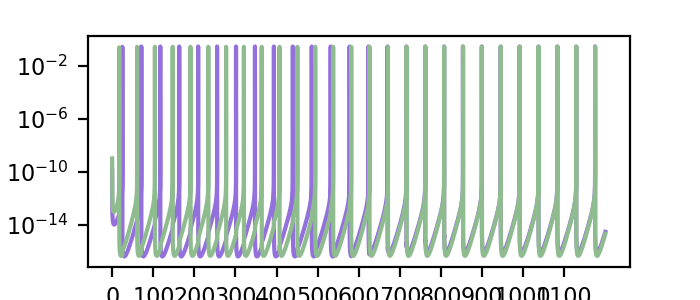

In [132]:
%matplotlib widget
fig, ax = plt.subplots(dpi=200, figsize=(3.5,1.5))
model.plot_results(ax=ax)
ax.set(
    xticks=np.arange(0, run_time, 100*3.15e7),
    xticklabels = [f'{int(_/3.15e7)}' for _ in np.arange(0,run_time, 100*3.15e7)],
    xlabel='Time (years)',
);


In [120]:
np.shape(model.time)

(189332,)

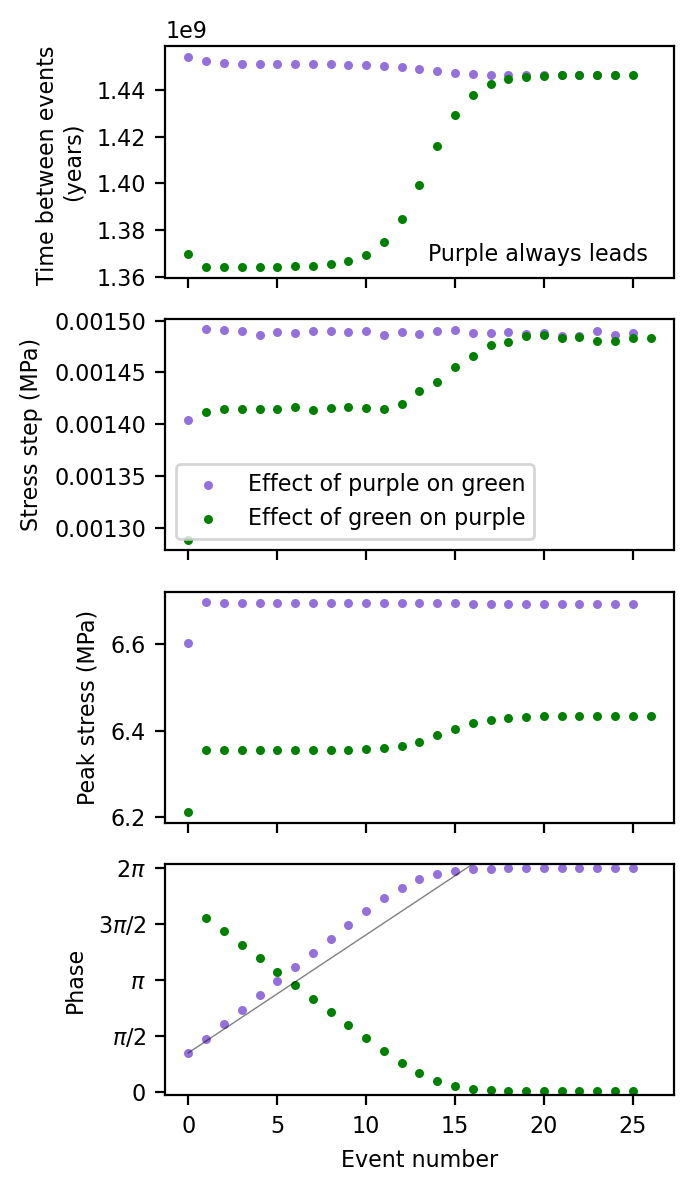

In [124]:
%matplotlib inline
tA, tB = model.get_events()

fig, AX = plt.subplots(4,1, figsize=(3.5,6), sharex=True, dpi=200)
ax = AX[0]
ax.scatter(range(len(tA)-1), np.diff(tA), c='mediumpurple', s=5)
ax.scatter(range(len(tB)-1), np.diff(tB), c='green', s=5)
ax.text(0.95,0.05, 'Purple always leads', ha='right', va='bottom', transform=ax.transAxes)
ax.set(
    ylabel='Time between events \n(years)',
)

def get_step(t, s, tq, eps=.1):
    return np.interp(tq+eps, t, s) - np.interp(tq-eps, t, s)

ax = AX[1]

# A in B
ax.scatter(
    range(len(tA)),
    [get_step(model.time, model.stress[1,:], tq) for tq in tA],
    c='mediumpurple',
    label="Effect of purple on green",
    s=5,
)

ax.scatter(
    range(len(tB)),
    [get_step(model.time, model.stress[0,:], tq) for tq in tB],
    c='green',
    label="Effect of green on purple",
    s=5,
    
)

ax.legend()

ax.set(
    ylabel='Stress step (MPa)',
)


# plot the peak stress
ax = AX[2]
def get_peak(t, s, tq, eps=5):
    return np.max(s[np.where(t >= tq-eps)[0][0]:np.where(t <= tq+eps)[0][-1]])

ax.scatter(
    range(len(tA)),
    [get_peak(model.time, model.stress[0,:], tq) for tq in tA],
    c='mediumpurple',
    s=5,
)

ax.scatter(
    range(len(tB)),
    [get_peak(model.time, model.stress[1,:], tq) for tq in tB],
    c='green',
    s=5,
)

ax.set(
    ylabel='Peak stress (MPa)',
)


ax = AX[3]
ax.scatter(
    range(len(tB)),
    [get_single_phase(tq, tA) for tq in tB],
    c='green',
    label="Phase of green in purple",
    s=5,
)

ax.scatter(
    range(len(tA)),
    [get_single_phase(tq, tB) for tq in tA],
    c='mediumpurple',
    label="Phase of purple in green",
    s=5,
)

dummy_x = np.linspace(0, len(tA), 100)
ax.plot(dummy_x, (10-9.5)/9.5*dummy_x * 2*np.pi + get_single_phase(tA[0], tB), c='k', alpha=0.5, linewidth=0.5)

ax.set(
    ylim=(-0.1, 2*np.pi+0.1),
    yticks=np.arange(0, 2*np.pi+1e-3, np.pi/2),
    yticklabels=[r'$0$',r'$\pi/2$',r'$\pi$',r'$3\pi/2$',r'$2\pi$'],
    xlabel='Event number',
    ylabel='Phase',
)

plt.tight_layout()



[[<matplotlib.axis.XTick at 0x314f3a2c0>,
 [Text(0.0, 0, '0'),
  Text(3150000000.0, 0, '100'),
  Text(6300000000.0, 0, '200'),
  Text(9450000000.0, 0, '300'),
  Text(12600000000.0, 0, '400'),
  Text(15750000000.0, 0, '500'),
  Text(18900000000.0, 0, '600'),
  Text(22050000000.0, 0, '700'),
  Text(25200000000.0, 0, '800'),
  Text(28350000000.0, 0, '900'),
  Text(31500000000.0, 0, '1000'),
  Text(34650000000.0, 0, '1100')],
 Text(0.5, 0, 'Time (years)')]

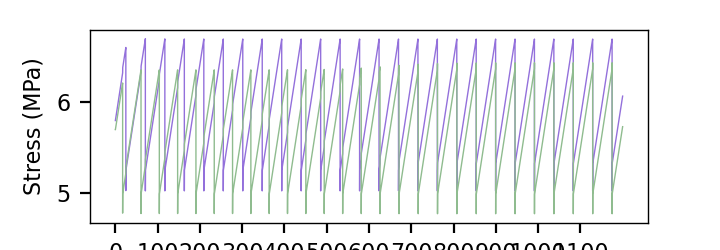

In [131]:
%matplotlib widget
fig, ax = plt.subplots(dpi=200, figsize=(3.6,1.25))
plt.rcParams['font.size'] = 8
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

model.plot_stress(ax=ax)
ax.set(
    xticks=np.arange(0, run_time, 100*3.15e7),
    xticklabels = [f'{int(_/3.15e7)}' for _ in np.arange(0,run_time, 100*3.15e7)],
    xlabel='Time (years)',
)

# save as pdf
# fig.savefig('stress.pdf', bbox_inches='tight')


In [123]:
sigma_2 = np.linspace(6,10,300)
number_of_random_times = 1000
run_time = 2000*3.15e7

def simulate_model(i_sigma2):
    model = CoupledSpringBlock(
        sigma=np.array([10.0,i_sigma2]), 
        Y=[np.random.uniform(-10,0),0,np.random.uniform(-10,0),0],
        k1=-1,
        k2=0.1,
        k3=0.1,
    )
    model.simulate(run_time)
    random_times = np.random.uniform(0.8*run_time,run_time,number_of_random_times)
    Y1 = np.interp(random_times,model.time,model.slip_deficit[0,:])
    Y2 = np.interp(random_times,model.time,model.slip_deficit[1,:])
    
    tA, tB = model.get_events()
    phases = [get_single_phase(tq, tA) for tq in tB]
    
    return Y1 - Y2, i_sigma2, phases

results = Parallel(n_jobs=-1)(delayed(simulate_model)(i_sigma2) for i_sigma2 in tqdm(sigma_2))

delta_Y, sigma_2_list, phases_list = zip(*results)

  4%|▍         | 12/300 [00:18<00:16, 17.14it/s]/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:90: RuntimeWarning: overflow encountered in exp
  V = Vpl_t * np.exp(Y[[0, 2]])
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:101: RuntimeWarning: invalid value encountered in subtract
  Yp[[0, 2]] = (kv - self.b * self.sigma * dth) / (
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:96: RuntimeWarning: overflow encountered in exp
  dth = (Vpl_t * np.exp(-th) - V) / self.dc  # change in RS state (theta)
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:90: RuntimeWarning: overflow encountered in exp
  V = Vpl_t * np.exp(Y[[0, 2]])
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders

KeyboardInterrupt: 

[Text(0.5, 0, 'Symmetry, $\\sigma_2$'), Text(0, 0.5, 'Phase of A in B')]

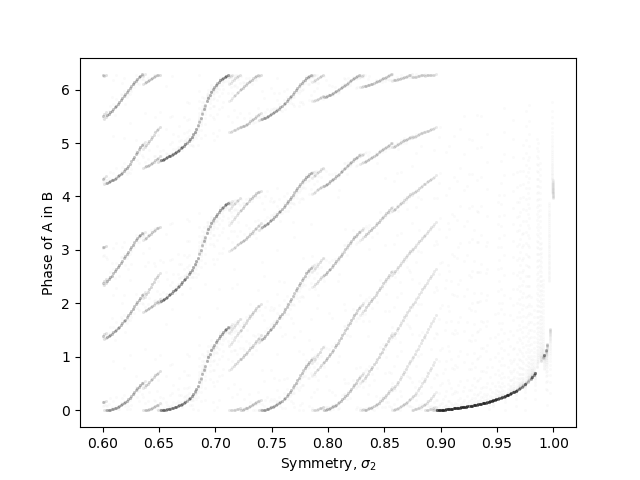

In [ ]:
fig, ax = plt.subplots()
for i_sigma2, i_phases in zip(sigma_2_list, phases_list):
    ax.scatter(i_sigma2*np.ones_like(i_phases)/10,i_phases, s=5, c='k', alpha=0.02, linewidth=0)
ax.set(
    xlabel=r'Symmetry, $\sigma_2$',
    ylabel=r'Phase of A in B',
)

[None]

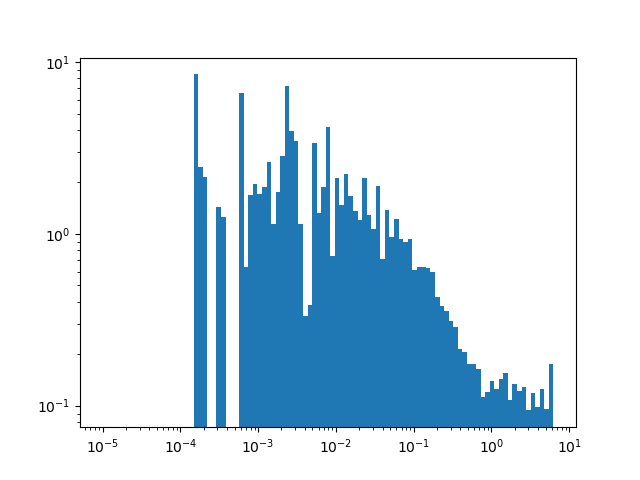

In [ ]:
fig, ax = plt.subplots()
bins = np.logspace(-5,np.log10(2*np.pi),100)
ax.hist(np.concatenate(phases_list), bins=bins, density=True, log=True)
ax.set(xscale='log')

/var/folders/nl/dmjw3blj27nd4c04v3dxnqw40000gn/T/ipykernel_2107/1139095191.py:37: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  plt.grid(b=None)


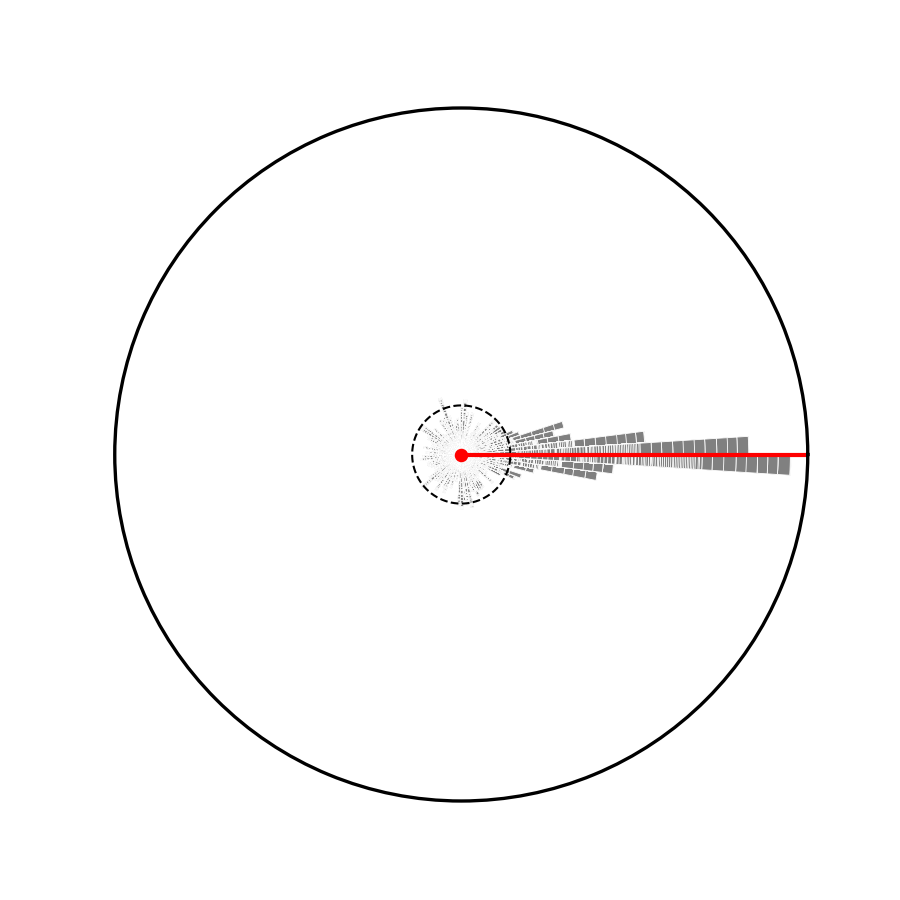

In [ ]:
plt.figure(figsize=(3, 3), dpi=300)
ax = plt.subplot(polar=True)

number_of_divisions = 100
bins = np.linspace(0, 2 * np.pi, number_of_divisions)

counts = []
for i_sigma2, i_phases in zip(sigma_2_list, phases_list):
    if np.random.random() > 0.5:
        i_phases = 2*np.pi - np.array(i_phases)
    counts.append(np.histogram(i_phases, bins)[0])

cummulative_counts = np.cumsum(counts, axis=0)

for i in range(len(phases_list)):
    ax.bar(
        0.5 * (bins[:-1] + bins[1:]),
        cummulative_counts[-i, :],
        width=2 * np.pi / number_of_divisions,
        color="grey",
        linewidth=0.2,
        edgecolor="white",
    )

ax.plot(
    np.linspace(0, 2 * np.pi, 100),
    [np.mean(cummulative_counts[-1, :])] * 100,
    c="k",
    lw=0.5,
    ls="--",
)

ax.axvline(c="r", lw=1)
ax.scatter(0, 0, c="r", s=5)
ax.set_rticks([])
ax.set_xticks([])
plt.grid(b=None)

Making an iterate map of the phase difference between the two blocks.

We can make this by first getting the times of the events and then computing the phase of block A in the occurence of B. 

Next we can plot the phase 

In [ ]:
model=CoupledSpringBlock(
        sigma=np.array([10.0,9.9]), 
        k2=0.021,
        k3=0.021,
        Y=[np.random.uniform(-10,0),0,np.random.uniform(-10,0),0],
)

model.simulate(900*3.15e7)

  message: 'The solver successfully reached the end of the integration interval.'
     nfev: 500720
     njev: 0
      nlu: 0
      sol: None
   status: 0
  success: True
        t: array([0.00000000e+00, 3.16067013e-01, 3.47673715e+00, ...,
       2.82261924e+10, 2.83261924e+10, 2.83500000e+10])
 t_events: None
        y: array([[-9.50198629e+00, -9.50198866e+00, -9.50201233e+00, ...,
        -9.09933678e+00, -8.12008996e+00, -7.86043262e+00],
       [ 0.00000000e+00,  1.58021576e-06,  1.73822361e-05, ...,
         8.57707947e+00,  8.57679038e+00,  8.55901598e+00],
       [-9.31027006e-01, -9.31028440e-01, -9.31042783e-01, ...,
        -1.07019782e+01, -9.83717291e+00, -9.62536078e+00],
       [ 0.00000000e+00,  9.57447730e-07,  1.05318909e-05, ...,
         8.46887749e+00,  8.55157854e+00,  8.56731574e+00]])
 y_events: None

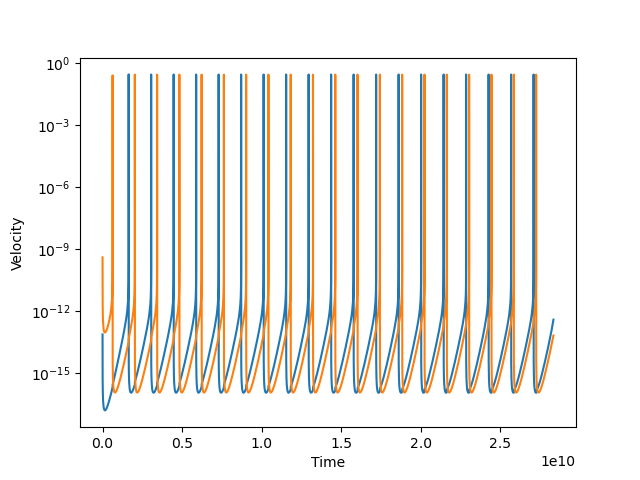

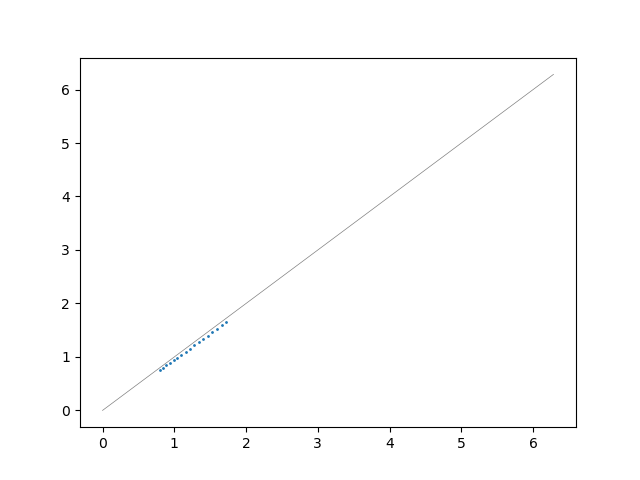

In [ ]:
ax = model.plot_results()
# ax.set(
#     yscale='linear'
# )

tA, tB = model.get_events()
phases = [get_single_phase(tq, tA) for tq in tB]

fig, ax = plt.subplots()
ax.scatter(phases[:-1],phases[1:], s=1)
ax.plot([0,2*np.pi],[0,2*np.pi], c='k', alpha=0.5, linewidth=0.5)

/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:96: RuntimeWarning: overflow encountered in exp
  dth = (Vpl_t * np.exp(-th) - V) / self.dc  # change in RS state (theta)
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:96: RuntimeWarning: invalid value encountered in subtract
  dth = (Vpl_t * np.exp(-th) - V) / self.dc  # change in RS state (theta)
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:90: RuntimeWarning: overflow encountered in exp
  V = Vpl_t * np.exp(Y[[0, 2]])
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sliders/two_spring_block.py:101: RuntimeWarning: invalid value encountered in subtract
  Yp[[0, 2]] = (kv - self.b * self.sigma * dth) / (
/Users/kdascher/Documents/Documents/Berkeley/Projects/Exploratory_projects/spring_block_sli

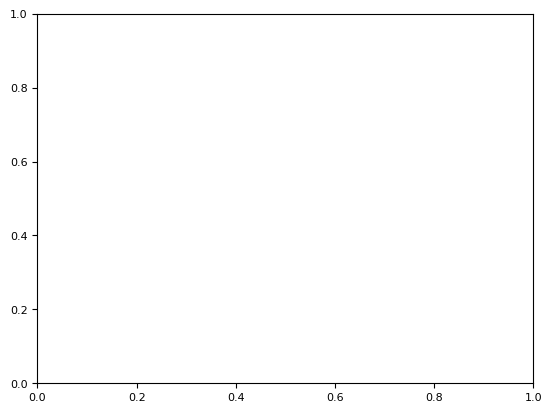

In [ ]:
number_of_simulations = 10

fig2, ax2 = plt.subplots()

run_time = 3000 * 3.15e7

def run_simulation(i):
    model = CoupledSpringBlock(
        sigma=np.array([10.0, 9.0]),
        k1=-1,
        k2=0.2,
        k3=0.2,
        Y=[np.random.uniform(-10, 0), 0, np.random.uniform(-10, 0), 0],
    )
    model.simulate(run_time)
        
    tA, tB = model.get_events()
    phases = [get_single_phase(tq, tA) for tq in tB]
    
    return model.time, model.slip_deficit[0, :] - model.slip_deficit[1, :], phases

results = Parallel(n_jobs=-1)(delayed(run_simulation)(i) for i in range(number_of_simulations))

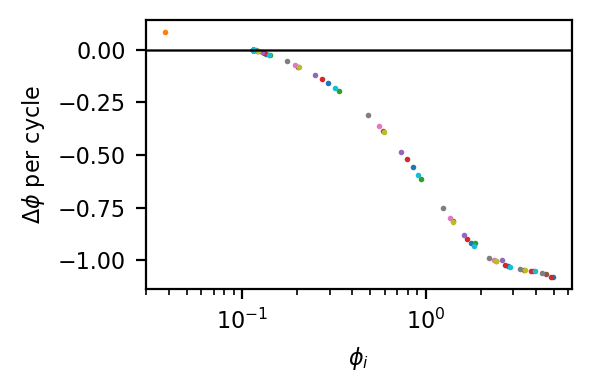

In [ ]:
fig2, ax2 = plt.subplots(dpi=200, figsize=(3,2))
time = []
delta_Y = []
all_phases = []

for t, dy, phases in results:
    time.append(t)
    delta_Y.append(dy)
    all_phases.append(phases)
    ax2.scatter(np.array(phases)[:-1], np.array(phases)[1:]-np.array(phases)[:-1], s=1)
    ax2.set(
        xscale='log',
        xlabel=r'$\phi_{i}$',
        ylabel=r'$\Delta \phi$ per cycle',
    )
    ax2.axhline(0, c='k', alpha=0.5, linewidth=0.5)

plt.tight_layout()

[Text(0.5, 0, '$\\phi_{i}$'),
 Text(0, 0.5, '$\\Delta \\phi_{i+1}$ per cycle'),
 [Text(0.0, 0, '$0$'),
  Text(1.5707963267948966, 0, '$\\pi/2$'),
  Text(3.141592653589793, 0, '$\\pi$'),
  Text(4.71238898038469, 0, '$3\\pi/2$'),
  Text(6.283185307179586, 0, '$2\\pi$')]]

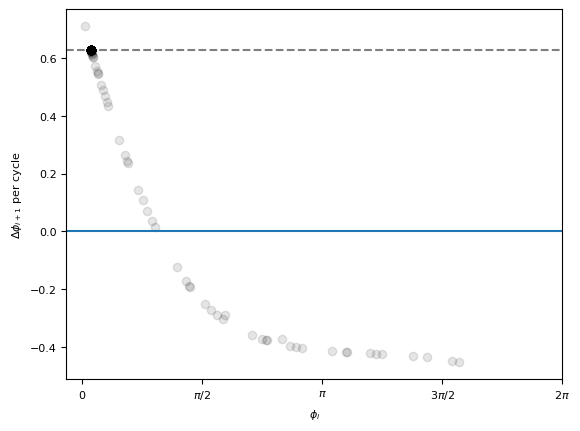

In [ ]:
fig, ax = plt.subplots()
for phases in all_phases:
    phases = np.array(phases)
    ax.scatter(phases[:-1], (phases[1:]-phases[:-1]) + 0.1*2*np.pi, alpha=0.1, c='k')

ax.axhline()
ax.axhline(0.1*2*np.pi, ls='--', c='k', alpha=0.5)
    
ax.set(
    xlabel=r'$\phi_{i}$',
    ylabel=r'$\Delta \phi_{i+1}$ per cycle',
    xticks=np.arange(0,2*np.pi+1e-3,np.pi/2),
    xticklabels=[r'$0$',r'$\pi/2$',r'$\pi$',r'$3\pi/2$',r'$2\pi$'],
)

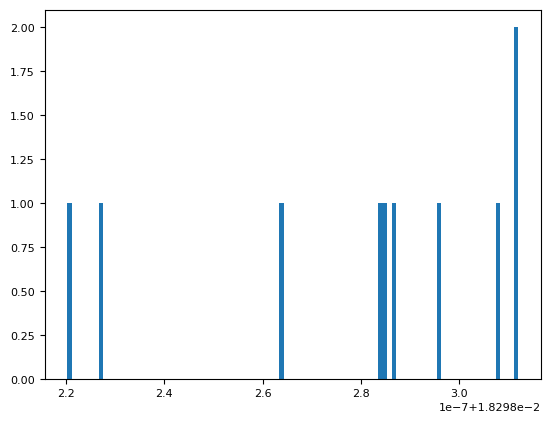

In [ ]:
fig, ax = plt.subplots()
ax.hist(np.concatenate([phases[-2:] for phases in all_phases])/2/np.pi, bins=100);

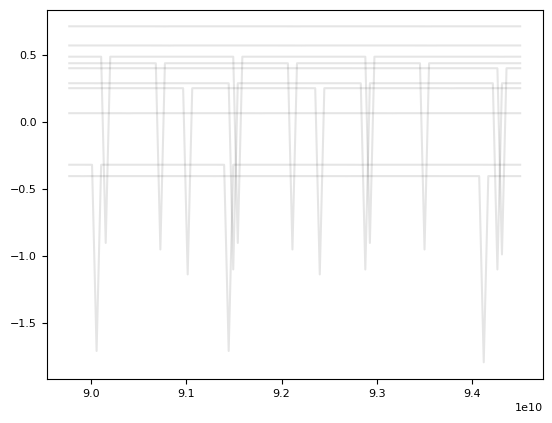

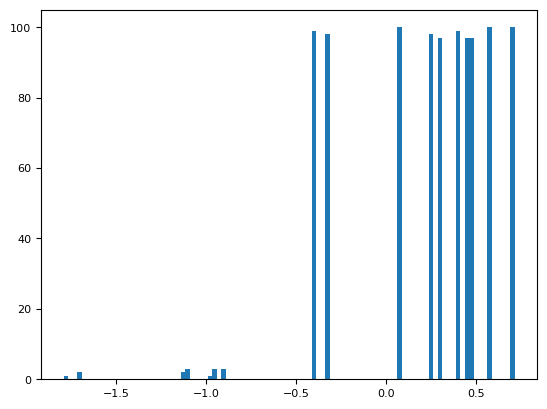

In [ ]:
delta_Y_interp = []
fig, ax = plt.subplots()
for t,dy in zip(time,delta_Y):
    tq = np.linspace(0.95, 1, 100) * run_time
    dy_interp = np.interp(tq, t, dy)
    delta_Y_interp.append(dy_interp)
    ax.plot(tq, dy_interp, alpha=0.1, c='k')
    

fig, ax = plt.subplots()
ax.hist(np.concatenate(delta_Y_interp), bins=100);


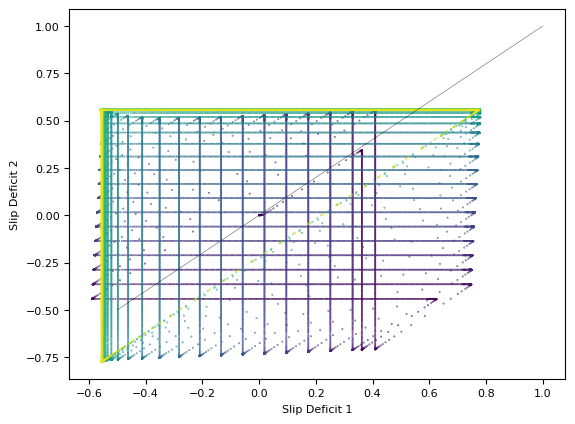

In [ ]:
ax = model.plot_orbits()
# plot 1:1 line
ax.plot([-0.5,1],[-0.5,1], c='k', alpha=0.5, linewidth=0.5)

# plot slip deficit ratio

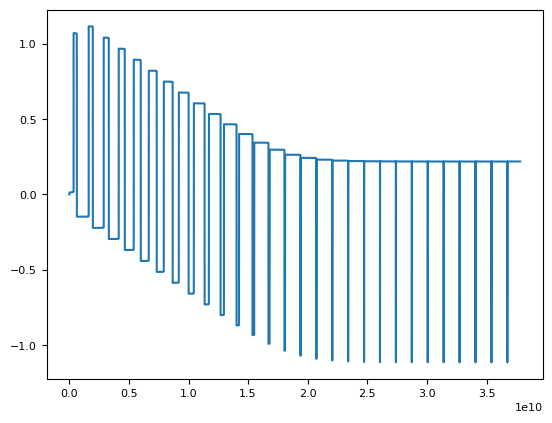

In [ ]:
fig, ax = plt.subplots()
ax.plot(model.time,model.slip_deficit[0,:] - model.slip_deficit[1,:]);

